# Session 09 02 2026
On that date I recorded a new session - I labeled the date so that I can validate the predictions of the current model

## Load model
First we are going to load the trained model from ML Flow

In [ ]:
import pandas as pd
stairs_up = pd.read_json(r"E:\src\neat-calculator\data_collection\recordings\sensor_data\SensorRecording\1770664526336.json", convert_dates=False)

first_timestamp = stairs_up['timestamp'].iloc[0]


# fill in every timestamp after the first one with 20ms intervals until the last timestamp
stairs_up['timestamp'] = first_timestamp + (stairs_up.index * 20)

stairs_up.to_json(r"E:\src\neat-calculator\data_collection\recordings\sensor_data\SensorRecording\1770664526336_filled.json", orient='records', date_format='epoch', date_unit='ms')

In [1]:
import sys
from pathlib import Path
import os
from dotenv import load_dotenv

load_dotenv()  # Load environment variables from .env file

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from data_pipeline.database import save_to_db, initialize_tables, update_pipeline_run_status
from infra.db.database_utils import DatabaseFactory
import os
from infra.db.database_utils import DatabaseEngine, get_postgres_db_engine

import logging
logger = logging.getLogger(__name__)
import mlflow
from load_model import load_production_model


MLFLOW_TRACKING_URI = os.getenv("MLFLOW_BACKEND_STORE_URI", None)
if MLFLOW_TRACKING_URI is None:
    raise ValueError("MLFLOW_TRACKING_URI environment variable is not set.")
MODEL_NAME = os.getenv("MODEL_NAME", "HAR_xgboost")
MODEL_ALIAS = os.getenv("MODEL_ALIAS", "production")

db_engine = get_postgres_db_engine()

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

# LOAD MODEL AND SCALER
model, scaler = load_production_model(MODEL_NAME, MODEL_ALIAS)
print(f"Loaded model: {MODEL_NAME} with alias: {MODEL_ALIAS}")

# Get detailed model information from MLflow
try:
    client = mlflow.MlflowClient()
    model_version = client.get_model_version_by_alias(MODEL_NAME, MODEL_ALIAS)
    
    print(f"\n=== MODEL DETAILS ===")
    print(f"Model Name: {model_version.name}")
    print(f"Version: {model_version.version}")
    print(f"Stage: {model_version.current_stage}")
    print(f"Description: {model_version.description or 'No description available'}")
    print(f"Created: {model_version.creation_timestamp}")
    print(f"Last Updated: {model_version.last_updated_timestamp}")
    print(f"Run ID: {model_version.run_id}")
    
    # Get run information for additional details
    run = client.get_run(model_version.run_id)
    print(f"\n=== TRAINING RUN DETAILS ===")
    print(f"Run Name: {run.info.run_name}")
    print(f"Start Time: {run.info.start_time}")
    print(f"End Time: {run.info.end_time}")
    print(f"Status: {run.info.status}")
    
    # Show key metrics if available
    if run.data.metrics:
        print(f"\n=== TRAINING METRICS ===")
        for metric_name, metric_value in run.data.metrics.items():
            print(f"  {metric_name}: {metric_value:.4f}")
    
    # Show parameters
    if run.data.params:
        print(f"\n=== MODEL PARAMETERS ===")
        for param_name, param_value in run.data.params.items():
            print(f"  {param_name}: {param_value}")

except Exception as e:
    print(f"Could not fetch detailed model info: {e}")

if scaler:
    print("\n✅ Scaler is available for data transformation.")
else:
    print("\n⚠️  WARNING: No scaler loaded. Predictions on raw data may be incorrect.")

print(f"\n=== MODEL INPUT SCHEMA ===")
if hasattr(model, 'metadata') and model.metadata.signature:
    input_schema = model.metadata.signature.inputs
    print(f"  Expected features: {len(input_schema.input_names())}")
    print(f"  First 5 features: {input_schema.input_names()[:5]}")
else:
    print("  No signature found in model metadata")

Loading model from MLflow URI: models:/HAR_xgboost@production


2026/02/09 20:34:53 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/09 20:34:53 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/09 20:34:53 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/09 20:34:53 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/09 20:34:53 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/09 20:34:53 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/09 20:34:54 INFO alembic.runtime.migration: Context impl PostgresqlImpl.
2026/02/09 20:34:54 INFO alembic.runtime.migration: Will assume transactional DDL.


✓ Scaler loaded successfully
Loaded model: HAR_xgboost with alias: production

=== MODEL DETAILS ===
Model Name: HAR_xgboost
Version: 20
Stage: None
Description: No description available
Created: 1770652056587
Last Updated: 1770652056587
Run ID: ae0188b51a614d359cff639cbfcdf406

=== TRAINING RUN DETAILS ===
Run Name: XGBoost_180_features
Start Time: 1770652046977
End Time: 1770652056688
Status: FINISHED

=== TRAINING METRICS ===
  accuracy: 0.8700

=== MODEL PARAMETERS ===
  n_features: 175
  n_classes: 6

✅ Scaler is available for data transformation.

=== MODEL INPUT SCHEMA ===
  No signature found in model metadata


model is loaded so time to run last processing and predictions

this is raw data. first we need to run it through data processing pipeline

In [11]:
import os
import sys
# Fix Unicode encoding issues on Windows

from data_pipeline.process_raw_data import process_raw_sensor_data
import pandas as pd

labels_with_timestamps_path = r"E:\src\neat-calculator\ml_monolith\data_preprocessing\labelss.csv"

print(f"\n{'='*50}")
print("Processing raw sensor data...")



try:
    processed_data = process_raw_sensor_data(
        raw_data_file_dir=r"E:\src\neat-calculator\data_collection\recordings\sensor_data\SensorRecording",
        kaggle_csv_path="E:\\src\\neat-calculator\\ml_monolith\\kaggle.csv",
        labels_csv_path=labels_with_timestamps_path,
        version="2"
    )
    print(f"✅ Processing successful!")
    print(f"  Data shape: {processed_data.shape}")
    print(f"  Columns: {list(processed_data.columns)}")
    
    if 'Activity' in processed_data.columns:
        print(f"  Activity distribution:")
        print(processed_data['Activity'].value_counts())
    else:
        print("  No Activity column found - processed without labels")
        
    processed_data.head()
    
except Exception as e:
    print(f"❌ Processing failed: {str(e)}")
    print(f"Error type: {type(e).__name__}")
    

2026-02-10 09:01:57,289 - data_pipeline.process_raw_data - INFO - Starting processing of raw data in directory: E:\src\neat-calculator\data_collection\recordings\sensor_data\SensorRecording
2026-02-10 09:01:57,289 - data_pipeline.process_raw_data - INFO - Using labels from: E:\src\neat-calculator\ml_monolith\data_preprocessing\labelss.csv


2026-02-10 09:01:57,289 - data_pipeline.process_raw_data - INFO - Validating directory: E:\src\neat-calculator\data_collection\recordings\sensor_data\SensorRecording
2026-02-10 09:01:57,303 - data_pipeline.process_raw_data - INFO - Directory E:\src\neat-calculator\data_collection\recordings\sensor_data\SensorRecording exists.
2026-02-10 09:01:57,304 - data_pipeline.process_raw_data - INFO - Path E:\src\neat-calculator\data_collection\recordings\sensor_data\SensorRecording is a directory.
2026-02-10 09:01:57,306 - data_pipeline.process_raw_data - INFO - Directory E:\src\neat-calculator\data_collection\recordings\sensor_data\SensorRecording is not empty.
2026-02-10 09:01:57,388 - data_pipeline.process_raw_data - INFO - All files in directory E:\src\neat-calculator\data_collection\recordings\sensor_data\SensorRecording are valid.
2026-02-10 09:01:57,388 - data_pipeline.process_raw_data - INFO - Merging JSON files from directory: E:\src\neat-calculator\data_collection\recordings\sensor_dat


Processing raw sensor data...


2026-02-10 09:01:57,538 - data_pipeline.process_raw_data - INFO - Total sensor data points: 6432
2026-02-10 09:01:57,542 - data_pipeline.process_raw_data - INFO - Timestamp range: 1770651054262 to 1770667757996
2026-02-10 09:01:57,542 - data_pipeline.process_raw_data - INFO - Processing 3 labels...
2026-02-10 09:01:57,542 - data_pipeline.process_raw_data - INFO - Label 1: Stairs Down
2026-02-10 09:01:57,542 - data_pipeline.process_raw_data - INFO -   Original range: 1770662854047 to 1770662889301
2026-02-10 09:01:57,542 - data_pipeline.process_raw_data - INFO -   Buffered range: 1770662854047 to 1770662889301
2026-02-10 09:01:57,553 - data_pipeline.process_raw_data - INFO - Labeled 218 sensor data points
2026-02-10 09:01:57,555 - data_pipeline.process_raw_data - INFO - Label 2: Stairs Up
2026-02-10 09:01:57,555 - data_pipeline.process_raw_data - INFO -   Original range: 1770664560555 to 1770664607205
2026-02-10 09:01:57,556 - data_pipeline.process_raw_data - INFO -   Buffered range: 17

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6432 entries, 0 to 6431
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   accelerometerX  6432 non-null   float64
 1   accelerometerY  6432 non-null   float64
 2   accelerometerZ  6432 non-null   float64
 3   gyroscopeX      6432 non-null   float64
 4   gyroscopeY      6432 non-null   float64
 5   gyroscopeZ      6432 non-null   float64
 6   timestamp       6432 non-null   int64  
 7   timestampNanos  6432 non-null   int64  
 8   label           1909 non-null   object 
dtypes: float64(6), int64(2), object(1)
memory usage: 452.4+ KB
{'accelerometerX': 'mean', 'accelerometerY': 'mean', 'accelerometerZ': 'mean', 'gyroscopeX': 'mean', 'gyroscopeY': 'mean', 'gyroscopeZ': 'mean'}
{'accelerometerX': 'mean', 'accelerometerY': 'mean', 'accelerometerZ': 'mean', 'gyroscopeX': 'mean', 'gyroscopeY': 'mean', 'gyroscopeZ': 'mean', 'label': 'first', 'timestamp': 'first'}


2026-02-10 09:01:58,453 - data_pipeline.process_raw_data - INFO - Median delta time: 0.02 seconds
2026-02-10 09:01:58,454 - data_pipeline.process_raw_data - INFO - Estimated frequency: 50.0 Hz
2026-02-10 09:01:58,455 - data_pipeline.process_raw_data - INFO - Resampling completed.
2026-02-10 09:01:58,456 - data_pipeline.process_raw_data - INFO - Columns after resampling: ['accelerometerX', 'accelerometerY', 'accelerometerZ', 'gyroscopeX', 'gyroscopeY', 'gyroscopeZ', 'label', 'timestamp', 'dt', 'dt_seconds']
2026-02-10 09:01:58,456 - data_pipeline.process_raw_data - INFO - Creating sliding windows with window size: 128, step size: 64
2026-02-10 09:01:58,458 - data_pipeline.process_raw_data - INFO - Identifying session breaks based on time gaps. A session means a singular recording session without big time gaps.
2026-02-10 09:01:58,458 - data_pipeline.process_raw_data - INFO - Number of sessions: 4
2026-02-10 09:01:58,491 - data_pipeline.process_raw_data - INFO - Sliding windows created.


                         dt_seconds  session_id
t                                              
2026-02-09 18:47:34.040        0.00           0
2026-02-09 18:47:34.060        0.02           0
2026-02-09 18:47:34.080        0.02           0
2026-02-09 18:47:34.100        0.02           0
2026-02-09 18:47:34.120        0.02           0
2026-02-09 18:47:34.140        0.02           0
2026-02-09 18:47:34.160        0.02           0
2026-02-09 18:47:34.180        0.02           0
2026-02-09 18:47:34.200        0.02           0
2026-02-09 18:47:34.220        0.02           0
Number of windows: 72
Window shape: (128, 6)
Example labels: ['WALKING_DOWNSTAIRS' 'WALKING_UPSTAIRS']


2026-02-10 09:01:59,103 - data_pipeline.process_raw_data - INFO - Shape of features: (72, 212)
2026-02-10 09:01:59,103 - data_pipeline.process_raw_data - INFO - Feature columns: Index(['tBodyAcc-mean()-X', 'tBodyAcc-std()-X', 'tBodyAcc-min()-X',
       'tBodyAcc-max()-X', 'tBodyAcc-energy()-X', 'tBodyAcc-entropy()-X',
       'tBodyAcc-mean()-Y', 'tBodyAcc-std()-Y', 'tBodyAcc-min()-Y',
       'tBodyAcc-max()-Y',
       ...
       'fBodyGyroMag-mean()', 'fBodyGyroMag-std()', 'fBodyGyroMag-energy()',
       'fBodyGyroMag-entropy()', 'fBodyGyroMag-meanFreq()',
       'fBodyGyroJerkMag-mean()', 'fBodyGyroJerkMag-std()',
       'fBodyGyroJerkMag-energy()', 'fBodyGyroJerkMag-entropy()',
       'fBodyGyroJerkMag-meanFreq()'],
      dtype='object', length=212)
2026-02-10 09:01:59,103 - data_pipeline.process_raw_data - INFO - Feature extraction completed.
2026-02-10 09:01:59,103 - data_pipeline.process_raw_data - INFO - Renaming features for clarity.
2026-02-10 09:01:59,103 - data_pipeline.proce

✅ Processing successful!
  Data shape: (72, 182)
  Columns: ['tBodyAcc-mean()-X', 'tBodyAcc-std()-X', 'tBodyAcc-min()-X', 'tBodyAcc-max()-X', 'tBodyAcc-energy()-X', 'tBodyAcc-entropy()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-std()-Y', 'tBodyAcc-min()-Y', 'tBodyAcc-max()-Y', 'tBodyAcc-energy()-Y', 'tBodyAcc-entropy()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-Z', 'tBodyAcc-min()-Z', 'tBodyAcc-max()-Z', 'tBodyAcc-energy()-Z', 'tBodyAcc-entropy()-Z', 'tBodyGyro-mean()-X', 'tBodyGyro-std()-X', 'tBodyGyro-min()-X', 'tBodyGyro-max()-X', 'tBodyGyro-energy()-X', 'tBodyGyro-entropy()-X', 'tBodyGyro-mean()-Y', 'tBodyGyro-std()-Y', 'tBodyGyro-min()-Y', 'tBodyGyro-max()-Y', 'tBodyGyro-energy()-Y', 'tBodyGyro-entropy()-Y', 'tBodyGyro-mean()-Z', 'tBodyGyro-std()-Z', 'tBodyGyro-min()-Z', 'tBodyGyro-max()-Z', 'tBodyGyro-energy()-Z', 'tBodyGyro-entropy()-Z', 'tGravityAcc-mean()-X', 'tGravityAcc-std()-X', 'tGravityAcc-min()-X', 'tGravityAcc-max()-X', 'tGravityAcc-energy()-X', 'tGravityAcc-entropy()-X', 'tGravi

In [12]:
# Debug timestamp ranges to see why "Stairs Up" is being skipped
import pandas as pd
import numpy as np

# Load the labels file to inspect
labels_path = r"E:\src\neat-calculator\ml_monolith\data_preprocessing\labels09022026.csv"
labels_df = pd.read_csv(labels_path)

print("=== LABELS ANALYSIS ===")
print(f"Labels in CSV file:")
for i, row in labels_df.iterrows():
    print(f"  {i+1}. {row['Label']}")
    print(f"     Start: {row['StartTimestamp_Unix_Ms']} ({pd.to_datetime(row['StartTimestamp_Unix_Ms'], unit='ms')})")
    print(f"     End:   {row['EndTimestamp_Unix_Ms']} ({pd.to_datetime(row['EndTimestamp_Unix_Ms'], unit='ms')})")
    
    # Calculate buffered range (same as in label_data_v2)
    start_buffered = row['StartTimestamp_Unix_Ms'] + 2000
    end_buffered = row['EndTimestamp_Unix_Ms'] - 2000
    print(f"     Buffered Start: {start_buffered} ({pd.to_datetime(start_buffered, unit='ms')})")
    print(f"     Buffered End:   {end_buffered} ({pd.to_datetime(end_buffered, unit='ms')})")
    print()

# Load one sensor file to check timestamp ranges
import json
import os

sensor_dir = r"E:\src\neat-calculator\data_collection\recordings\sensor_data\SensorRecording"
sensor_files = [f for f in os.listdir(sensor_dir) if f.endswith('.json')]
sensor_files.sort()

print("=== SENSOR DATA ANALYSIS ===")
print(f"Available sensor files: {len(sensor_files)}")

all_timestamps = []
for filename in sensor_files[:3]:  # Check first 3 files
    filepath = os.path.join(sensor_dir, filename)
    with open(filepath, 'r') as f:
        data = json.load(f)
        timestamps = [item['timestamp'] for item in data]
        all_timestamps.extend(timestamps)
    print(f"File: {filename}")
    print(f"  Timestamp range: {min(timestamps)} to {max(timestamps)}")
    print(f"  Time range: {pd.to_datetime(min(timestamps), unit='ms')} to {pd.to_datetime(max(timestamps), unit='ms')}")
    print(f"  Data points: {len(timestamps)}")

print(f"\nOverall sensor timestamp range: {min(all_timestamps)} to {max(all_timestamps)}")
print(f"Overall time range: {pd.to_datetime(min(all_timestamps), unit='ms')} to {pd.to_datetime(max(all_timestamps), unit='ms')}")

# Check for gaps around "Stairs Up" time
stairs_up_row = labels_df[labels_df['Label'] == 'Stairs Up'].iloc[0]
stairs_up_start = stairs_up_row['StartTimestamp_Unix_Ms'] + 2000
stairs_up_end = stairs_up_row['EndTimestamp_Unix_Ms'] - 2000

print(f"\n=== STAIRS UP INVESTIGATION ===")
print(f"Looking for timestamps between {stairs_up_start} and {stairs_up_end}")

# Check which sensor data points are closest to this range
in_range_count = len([t for t in all_timestamps if stairs_up_start <= t <= stairs_up_end])
before_range = [t for t in all_timestamps if t < stairs_up_start]
after_range = [t for t in all_timestamps if t > stairs_up_end]

print(f"Timestamps in Stairs Up range: {in_range_count}")
if before_range:
    closest_before = max(before_range)
    print(f"Closest timestamp before range: {closest_before} ({pd.to_datetime(closest_before, unit='ms')})")
    print(f"Gap before: {stairs_up_start - closest_before} ms")

if after_range:
    closest_after = min(after_range)
    print(f"Closest timestamp after range: {closest_after} ({pd.to_datetime(closest_after, unit='ms')})")
    print(f"Gap after: {closest_after - stairs_up_end} ms")

=== LABELS ANALYSIS ===
Labels in CSV file:
  1. Stairs Down
     Start: 1770644678745 (2026-02-09 13:44:38.745000)
     End:   1770644723179 (2026-02-09 13:45:23.179000)
     Buffered Start: 1770644680745 (2026-02-09 13:44:40.745000)
     Buffered End:   1770644721179 (2026-02-09 13:45:21.179000)

  2. Stairs Up
     Start: 1770644736599 (2026-02-09 13:45:36.599000)
     End:   1770644783209 (2026-02-09 13:46:23.209000)
     Buffered Start: 1770644738599 (2026-02-09 13:45:38.599000)
     Buffered End:   1770644781209 (2026-02-09 13:46:21.209000)

=== SENSOR DATA ANALYSIS ===
Available sensor files: 5
File: 1770651054261.json
  Timestamp range: 1770651054262 to 1770651096564
  Time range: 2026-02-09 15:30:54.262000 to 2026-02-09 15:31:36.564000
  Data points: 1188
File: 1770651106669.json
  Timestamp range: 1770651106687 to 1770651150465
  Time range: 2026-02-09 15:31:46.687000 to 2026-02-09 15:32:30.465000
  Data points: 1830
File: 1770662751591.json
  Timestamp range: 1770662751600 t

Okay we processed the data so time to fit it

In [13]:

if model_version.version == 17 or model_version.version == 20:
    to_drop_patterns = ['angle', 'tGravityAcc-X', 'tGravityAcc-Y', 'tGravityAcc-Z', 
                        'tBodyAcc-X', 'tBodyAcc-Y', 'tBodyAcc-Z',
                        'fBodyAcc-X', 'fBodyAcc-Y', 'fBodyAcc-Z']
        
    cols_to_drop = [col for col in processed_data.columns if any(pat in col for pat in to_drop_patterns)]
    logger.info(f"Found {len(cols_to_drop)} columns to drop: {cols_to_drop}")
    logger.info(f"Original shape: {processed_data.shape}")

    # Actually drop the columns (assign result back to processed_data)
    processed_data = processed_data.drop(columns=cols_to_drop)
    logger.info(f"New shape after dropping: {processed_data.shape}")
else: 
    print("using all 180 features")
    

2026-02-10 09:02:13,872 - __main__ - INFO - Found 5 columns to drop: ['angle(tBodyGyroMean,gravityMean)', 'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)', 'angle(Y,gravityMean)', 'angle(Z,gravityMean)']
2026-02-10 09:02:13,873 - __main__ - INFO - Original shape: (72, 182)
2026-02-10 09:02:13,875 - __main__ - INFO - New shape after dropping: (72, 177)


In [14]:
 # Use balanced data for prediction
import pandas as pd
from sklearn.preprocessing import LabelEncoder

filtered_data = processed_data

columns_to_drop = ["Activity", "timestamp"]
feature_columns = [col for col in filtered_data.columns if col not in columns_to_drop]

# ORIGINAL RAW DATA
# Extract raw features from processed data
X= filtered_data[feature_columns]
y = filtered_data["Activity"].to_numpy()

print(f"Feature matrix shape: {X.shape}")
print(f"Raw Data range: [{X.min().min():.2f}, {X.max().max():.2f}]")

# APPLY SCALER IF AVAILABLE
if scaler:
    print("Applying scaler to input data...")
    # Filter columns that scaler expects
    # (Assuming scaler was fit on same feature set. If mismatch, we might need intersection)
    try:
        X_scaled = scaler.transform(X)
        print(f"Scaled Data range: [{X_scaled.min():.2f}, {X_scaled.max():.2f}]")
        # Make predictions using the SCALED data
        predictions = model.predict(X_scaled)          # Returns integer labels
        probabilities = model.predict_proba(X_scaled)  # Probability matrix
    except Exception as e:
        print(f"Scaling failed: {e}")
        print("Falling back to raw data (results may be poor)")
        predictions = model.predict(X)
        probabilities = model.predict_proba(X)
else:
    print("WARNING: Using raw unscaled data.")
    predictions = model.predict(X)
    probabilities = model.predict_proba(X)


print(f"\nPredictions shape: {predictions.shape}")
print(f"Probabilities shape: {probabilities.shape}")
print(f"\nFirst 5 predictions (integers): {predictions[:5]}")
print(f"First prediction probabilities: {probabilities[0]}")


Feature matrix shape: (72, 175)
Raw Data range: [-638.00, 61363.90]
Applying scaler to input data...
Scaled Data range: [-1.43, 3.62]

Predictions shape: (72,)
Probabilities shape: (72, 6)

First 5 predictions (integers): [4 3 4 4 4]
First prediction probabilities: [0.01063184 0.01716068 0.04691964 0.22432525 0.42411506 0.2768475 ]


In [ ]:
y

In [15]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# The model was trained with LabelEncoder which sorts classes alphabetically by default
known_classes = ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']
le = LabelEncoder()
le.fit(known_classes)

# Inspect inputs
print(f"Type of y: {y.dtype}")
print(f"Type of predictions: {predictions.dtype}")
print(f"Unique values in predictions: {np.unique(predictions)}")

# Handle potential classes falling outside known classes
# It seems the model predicts a class (e.g., 6) that is outside the range 0-5.
# This can happen if the model was trained with more classes or if something is wrong.
# We will clip or map unknown classes to a placeholder or nearest valid class.

if np.issubdtype(predictions.dtype, np.number):
    print("Converting predictions from integers to string labels...")
    
    # Check for invalid labels
    invalid_mask = ~np.isin(predictions, np.arange(len(known_classes)))
    if invalid_mask.any():
        print(f"WARNING: Found {np.sum(invalid_mask)} predictions with invalid labels: {np.unique(predictions[invalid_mask])}")
        print("Mapping invalid labels to 'UNKNOWN' (or handling gracefully)")
        # Option 1: Clip to valid range (dangerous if mapping is wrong)
        # Option 2: Replace with dummy (-1) and handle transform manually
        
        # Here we'll convert manually to be safe
        pred_strings = []
        for p in predictions:
            if 0 <= p < len(known_classes):
                pred_strings.append(known_classes[p])
            else:
                pred_strings.append("UNKNOWN")
        predictions = np.array(pred_strings)
    else:
        predictions = le.inverse_transform(predictions.astype(int))

# Ensure y is string
y = y.astype(str)

print(f"First 5 ground truth: {y[:5]}")
print(f"First 5 predictions:  {predictions[:5]}")

Type of y: object
Type of predictions: int64
Unique values in predictions: [2 3 4 5]
Converting predictions from integers to string labels...
First 5 ground truth: ['WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS'
 'WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS']
First 5 predictions:  ['WALKING_DOWNSTAIRS' 'WALKING' 'WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS'
 'WALKING_DOWNSTAIRS']


In [16]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 1. Fix Label Mapping
# The model was trained with LabelEncoder which sorts classes alphabetically by default/standard HAR.
known_classes = ['LAYING','WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'WALKING',  'WALKING_UPSTAIRS']
le = LabelEncoder()
le.fit(known_classes)

# Inspect inputs
print(f"Type of y: {y.dtype}")
print(f"Type of predictions: {predictions.dtype}")

# Convert predictions (integers) back to string labels to match y
if np.issubdtype(predictions.dtype, np.number):
    print("Converting predictions from integers to string labels...")
    predictions = le.inverse_transform(predictions.astype(int))

# Ensure y is string
y = y.astype(str)

print(f"First 5 ground truth: {y[:5]}")
print(f"First 5 predictions:  {predictions[:5]}")


# 2. Check Feature Scaling (Likely Cause of Bad Performance)
# Kaggle HAR data is normalized to [-1, 1]. 
# Any values outside this range indicate a scaling mismatch using raw features.
print("\n--- Feature Scaling Check ---")
min_val = processed_data[feature_columns].min().min()
max_val = processed_data[feature_columns].max().max()
print(f"Min feature value: {min_val:.4f}")
print(f"Max feature value: {max_val:.4f}")

if min_val < -1.5 or max_val > 1.5:
    print("\n[WARNING] Feature values are outside the expected [-1, 1] range.")
    print("The model expects normalized data. Raw physical units will cause poor performance.")
    
    # Show top features violating range
    means = processed_data[feature_columns].mean()
    print("\nTop 5 features with highest mean values (likely unnormalized):")
    print(means.nlargest(5))
else:
    print("\n[OK] Feature values seem to be within normalized range.")

Type of y: <U18
Type of predictions: <U18
First 5 ground truth: ['WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS'
 'WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS']
First 5 predictions:  ['WALKING_DOWNSTAIRS' 'WALKING' 'WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS'
 'WALKING_DOWNSTAIRS']

--- Feature Scaling Check ---
Min feature value: -638.0000
Max feature value: 61363.8955

[WARNING] Feature values are outside the expected [-1, 1] range.
The model expects normalized data. Raw physical units will cause poor performance.

Top 5 features with highest mean values (likely unnormalized):
fBodyAccJerk-energy()-Z      13232.186733
fBodyAccJerk-energy()-Y      12036.343324
fBodyAccJerk-energy()-X      11535.132789
tBodyGyroJerkMag-energy()     2738.835498
tBodyGyroJerk-energy()-Y      1738.275282
dtype: float64


Accuracy: 0.6667

Classification Report:
                    precision    recall  f1-score   support

          STANDING       0.00      0.00      0.00         0
           WALKING       0.00      0.00      0.00         0
WALKING_DOWNSTAIRS       0.79      0.79      0.79        28
  WALKING_UPSTAIRS       0.93      0.59      0.72        44

          accuracy                           0.67        72
         macro avg       0.43      0.34      0.38        72
      weighted avg       0.87      0.67      0.75        72



e:\src\neat-calculator\ml_monolith\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\src\neat-calculator\ml_monolith\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\src\neat-calculator\ml_monolith\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


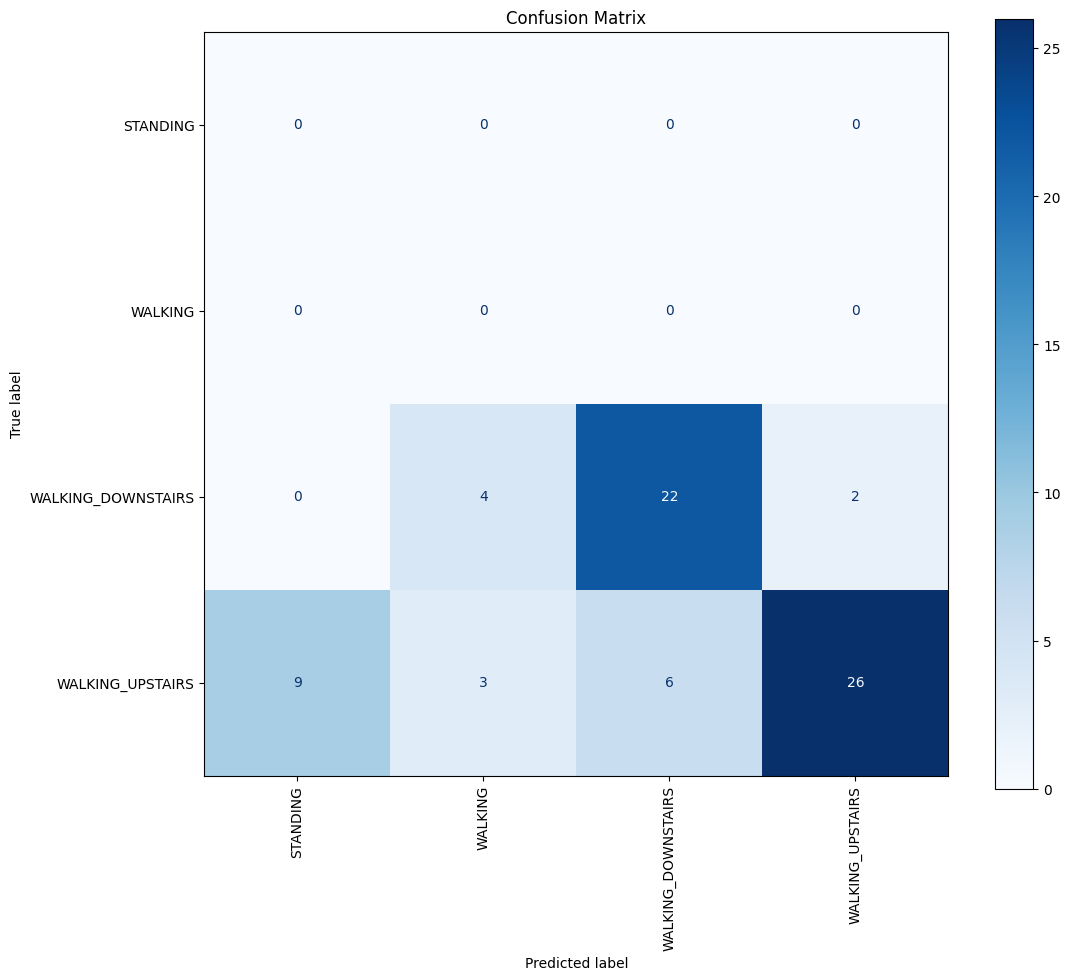

In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Calculate accuracy
accuracy = accuracy_score(y, predictions)
print(f"Accuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y, predictions))

# Confusion Matrix
# Ensure we capture all classes present in data and predictions
labels = np.unique(np.concatenate((y, predictions)))

fig, ax = plt.subplots(figsize=(12, 10))
cm = confusion_matrix(y, predictions, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

### Scaling Issue Identified
The model was trained on a combined dataset (Kaggle + Custom) where Kaggle data was scaled to [-1, 1] but Custom data was likely unscaled. This mixed distribution confuses the model.

**Next Steps:**
1. We have updated `train_model.py` to include `MinMaxScaler`.
2. You need to **re-run the training script** to generate a corrected model.
3. Then, reload the model here.


In [ ]:
# Re-training instructions
# To address the scaling mismatch, I've updated 'train_model.py' to scale your custom data to [-1, 1] before combining with Kaggle data.
# Please run the updated training script from the terminal:
# python ml_monolith/model_training/train_model.py


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Debug: Visualize Feature Variance vs Labels to Check Alignment
# "Walking" should have high variance (std/energy), "Standing" should be near zero.

plt.figure(figsize=(20, 6))

# Choose a key feature representing intensity
metric = "tBodyAcc-std()-X"  # Standard deviation of body acceleration (Jerk/Energy proxy)

if metric not in filtered_data.columns:
    print(f"Feature {metric} not found. Using first available feature.")
    metric = filtered_data.columns[0]

# Plot the feature value
sns.lineplot(data=filtered_data, x="timestamp", y=metric, label=metric, color='blue', alpha=0.6)

# Overlay the ground truth labels
# We create diverse colors for activities
unique_activities = filtered_data["Activity"].unique()
palette = sns.color_palette("hsv", len(unique_activities))
activity_colors = dict(zip(unique_activities, palette))

# Create a "step" plot for labels (scaled to fit the graph)
# Mapping labels to a numeric y-value for visualization? 
# Better: shade the background or add a scatter plot.
# Let's add a scatter plot on top for the labels.

# Map activities to y-positions or just color
# We'll plot points at the top of the graph colored by activity
max_y = filtered_data[metric].max()
sns.scatterplot(data=filtered_data, x="timestamp", y=max_y * 1.1, hue="Activity", palette=palette, s=50, marker="o")

plt.title(f"Activity Signals Analysis: {metric} vs Time")
plt.ylabel("Signal Intensity (Std Dev)")
plt.xlabel("Time")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

# Histogram check
plt.figure(figsize=(10, 6))
sns.boxplot(data=filtered_data, x="Activity", y=metric)
plt.title(f"Distribution of {metric} by Activity Label")
plt.xticks(rotation=45)
plt.show()


In [ ]:
# Extract and visualize feature importance from the loaded XGBoost model
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("=== MODEL FEATURE IMPORTANCE ===")

# Get feature importance from the model
if hasattr(model, 'feature_importances_'):
    feature_importance = model.feature_importances_
    
    # Create a DataFrame with feature names and importance scores
    importance_df = pd.DataFrame({
        'feature': feature_columns,
        'importance': feature_importance
    }).sort_values('importance', ascending=False)
    
    print(f"Total features: {len(feature_columns)}")
    print(f"\nTop 20 Most Important Features:")
    print(importance_df.head(20).to_string(index=False))
    
    # Visualization
    plt.figure(figsize=(12, 10))
    
    # Plot top 20 features
    top_features = importance_df.head(20)
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Feature Importance')
    plt.title('Top 20 Feature Importances (XGBoost Model)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    # Show statistics
    print(f"\nFeature Importance Statistics:")
    print(f"  Mean: {importance_df['importance'].mean():.6f}")
    print(f"  Std:  {importance_df['importance'].std():.6f}")
    print(f"  Max:  {importance_df['importance'].max():.6f} ({importance_df.iloc[0]['feature']})")
    print(f"  Min:  {importance_df['importance'].min():.6f} ({importance_df.iloc[-1]['feature']})")
    
    # Show feature categories breakdown
    print(f"\nFeature Category Breakdown:")
    categories = {}
    for feature in importance_df['feature']:
        if 'Acc' in feature:
            category = 'Accelerometer'
        elif 'Gyro' in feature:
            category = 'Gyroscope' 
        elif 'Mag' in feature:
            category = 'Magnetometer'
        elif 'Gravity' in feature:
            category = 'Gravity'
        elif 'Jerk' in feature:
            category = 'Jerk'
        else:
            category = 'Other'
        
        if category not in categories:
            categories[category] = []
        categories[category].append(feature)
    
    for cat, features in categories.items():
        avg_importance = importance_df[importance_df['feature'].isin(features)]['importance'].mean()
        print(f"  {cat}: {len(features)} features, avg importance: {avg_importance:.6f}")

else:
    print("❌ Model does not have feature_importances_ attribute")
    print(f"Model type: {type(model)}")
    
    # Try alternative methods for getting feature importance
    if hasattr(model, 'get_booster'):
        booster = model.get_booster()
        importance_dict = booster.get_score(importance_type='weight')
        print(f"Available importance from booster: {len(importance_dict)} features")
        
        # Convert to DataFrame
        importance_df = pd.DataFrame([
            {'feature': k, 'importance': v} 
            for k, v in importance_dict.items()
        ]).sort_values('importance', ascending=False)
        
        print(f"\nTop 10 Features (from booster):")
        print(importance_df.head(10))